# DisasterM3 — Dataset Inspection & Manifest Discovery
**Purpose:** Step 0 of the DisasterM3 reproduction pipeline.  
Download only the manifest (`train_release.json`, 87 MB) and explore the schema,
task distribution, sensor types, and image path references — *before* committing
to the 29.7 GB `train_images.zip` download.

**Runtime:** CPU-only (no GPU quota burned).  
**Reference:** Wang et al., NeurIPS 2025 — arXiv:2505.21089v2

In [3]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────
# Pin versions for reproducibility. huggingface_hub[hf_xet] enables the fast
# xet backend used by this dataset.
!pip install -q huggingface_hub[hf_xet] matplotlib pandas

## 1. Download the Manifest Only
We grab `train_release.json` (87 MB) and `benchmark_release.json` (21.7 MB)
without touching the multi-GB image zips.

In [4]:
# ── Cell 2: Download manifests ────────────────────────────────────────────
from huggingface_hub import hf_hub_download
import os

REPO_ID = "Kingdrone-Junjue/DisasterM3"
LOCAL_DIR = "/tmp/disasterm3"

# Instruct manifest (training)
train_manifest_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="DisasterM3_Instruct/train_release.json", # <--- Fixed
    repo_type="dataset",
    local_dir=LOCAL_DIR,
)

print(f"✓ Train manifest: {train_manifest_path}")
print(f"  Size: {os.path.getsize(train_manifest_path) / 1e6:.1f} MB")

# Bench manifest (evaluation)
bench_manifest_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="DisasterM3_Bench/benchmark_release.json", # <--- Fixed
    repo_type="dataset",
    local_dir=LOCAL_DIR,
)

print(f"✓ Bench manifest: {bench_manifest_path}")
print(f"  Size: {os.path.getsize(bench_manifest_path) / 1e6:.1f} MB")

DisasterM3_Instruct/train_release.json:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✓ Train manifest: /tmp/disasterm3/DisasterM3_Instruct/train_release.json
  Size: 87.3 MB


DisasterM3_Bench/benchmark_release.json:   0%|          | 0.00/21.7M [00:00<?, ?B/s]

✓ Bench manifest: /tmp/disasterm3/DisasterM3_Bench/benchmark_release.json
  Size: 21.7 MB


## 2. Load & Inspect Schema

In [5]:
# ── Cell 3: Load and inspect ──────────────────────────────────────────────
import json

with open(train_manifest_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(bench_manifest_path, "r", encoding="utf-8") as f:
    bench_data = json.load(f)

print(f"Instruct set: {len(train_data):,} entries")
print(f"Bench set:    {len(bench_data):,} entries")
print(f"Total:        {len(train_data) + len(bench_data):,} entries")
print()

# Show first entry
print("═" * 70)
print("SAMPLE ENTRY (first in Instruct set):")
print("═" * 70)
print(json.dumps(train_data[0], indent=2, ensure_ascii=False))

Instruct set: 92,968 entries
Bench set:    30,042 entries
Total:        123,010 entries

══════════════════════════════════════════════════════════════════════
SAMPLE ENTRY (first in Instruct set):
══════════════════════════════════════════════════════════════════════
{
  "pre_image_path": "train_images\\bata_explosion_pre_0.png",
  "post_image_path": "train_images\\bata_explosion_post_0.png",
  "post_image_type": "Optical",
  "ground_truth": "Buildings, Roads, Forest, Farmland",
  "ground_truth_option": "B, E, F, G.",
  "options_list": [
    "Stadiums",
    "Buildings",
    "Coastline",
    "Bridges",
    "Farmland",
    "Forest",
    "Roads",
    "Port facilities"
  ],
  "options_str": "A. Stadiums, B. Buildings, C. Coastline, D. Bridges, E. Farmland, F. Forest, G. Roads, H. Port facilities.",
  "prompts": "What essential land-cover objects appear damaged in this disaster zone?",
  "training_answer": "The essential land-cover objects that appear damaged in this disaster zone include 

## 3. Task Distribution

In [6]:
# ── Cell 4: Task distribution ─────────────────────────────────────────────
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# ── Instruct set ──
train_tasks = Counter(e.get("task", "MISSING") for e in train_data)
print("═" * 70)
print("INSTRUCT SET — Task Distribution")
print("═" * 70)
for task, count in train_tasks.most_common():
    pct = count / len(train_data) * 100
    print(f"  {task:<45} {count:>6,}  ({pct:.1f}%)")

# ── Bench set ──
bench_tasks = Counter(e.get("task", "MISSING") for e in bench_data)
print()
print("═" * 70)
print("BENCH SET — Task Distribution")
print("═" * 70)
for task, count in bench_tasks.most_common():
    pct = count / len(bench_data) * 100
    print(f"  {task:<45} {count:>6,}  ({pct:.1f}%)")

══════════════════════════════════════════════════════════════════════
INSTRUCT SET — Task Distribution
══════════════════════════════════════════════════════════════════════
  Referring Expression Segmentation             37,204  (40.0%)
  Building Damage Counting                      14,531  (15.6%)
  Disaster Bearing Bodies Recognition            7,766  (8.4%)
  disaster caption                               7,766  (8.4%)
  disaster restoration advice                    7,765  (8.4%)
  Road Damage Counting                           7,337  (7.9%)
  Disaster Scene Recognition                     7,090  (7.6%)
  relational reasoning                           1,882  (2.0%)
  Disaster Type Recognition                      1,627  (1.8%)

══════════════════════════════════════════════════════════════════════
BENCH SET — Task Distribution
══════════════════════════════════════════════════════════════════════
  Referring Expression Segmentation             12,348  (41.1%)
  Building Damage C

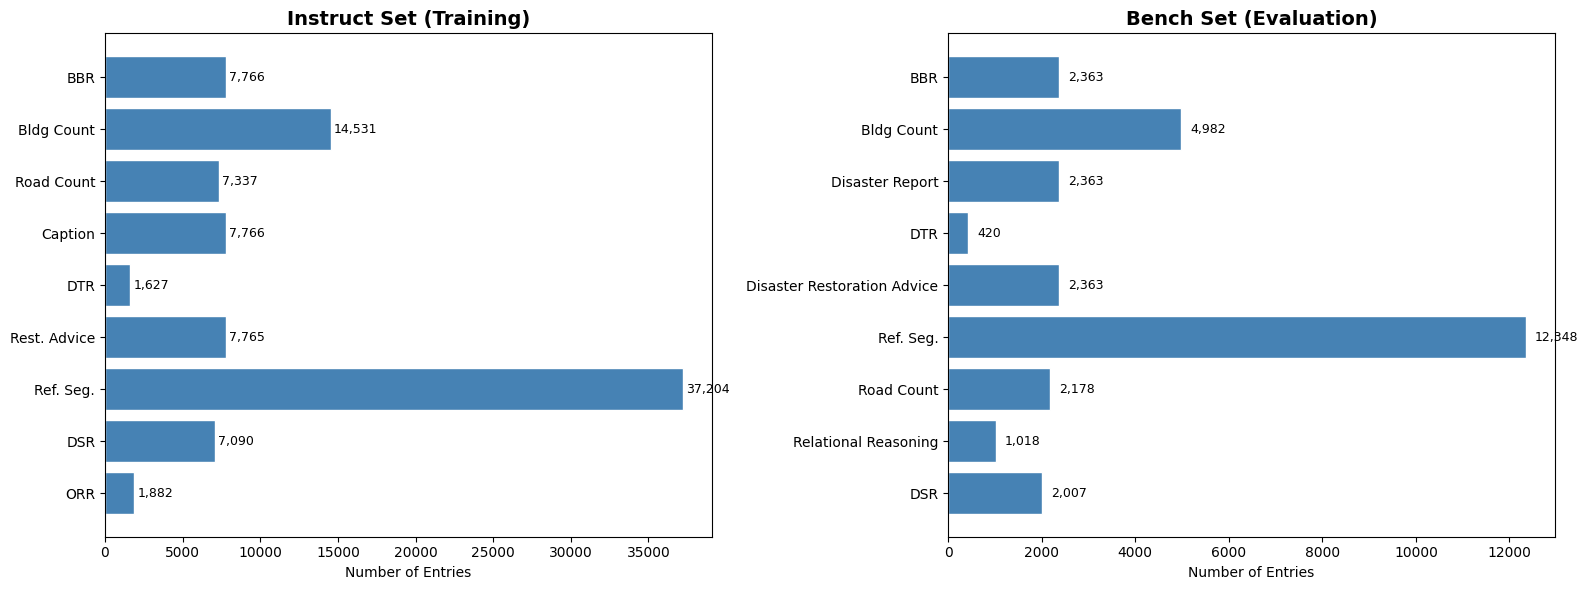

Saved to /tmp/disasterm3_task_distribution.png


In [7]:
# ── Cell 5: Visualize task distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Short labels for readability
label_map = {
    "Referring Expression Segmentation": "Ref. Seg.",
    "Building Damage Counting": "Bldg Count",
    "Disaster Bearing Bodies Recognition": "BBR",
    "disaster caption": "Caption",
    "disaster restoration advice": "Rest. Advice",
    "Road Damage Counting": "Road Count",
    "Disaster Scene Recognition": "DSR",
    "relational reasoning": "ORR",
    "Disaster Type Recognition": "DTR",
}

for ax, (title, task_counter) in zip(axes, [
    ("Instruct Set (Training)", train_tasks),
    ("Bench Set (Evaluation)", bench_tasks),
]):
    labels = [label_map.get(t, t) for t in task_counter.keys()]
    counts = list(task_counter.values())
    bars = ax.barh(labels, counts, color="steelblue", edgecolor="white")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Number of Entries")
    ax.invert_yaxis()
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                f"{count:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/tmp/disasterm3_task_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /tmp/disasterm3_task_distribution.png")

## 4. Sensor Type Distribution

In [8]:
# ── Cell 6: Sensor types ──────────────────────────────────────────────────
train_sensors = Counter()
for e in train_data:
    sensor = e.get("post_image_type", e.get("image_type", "MISSING"))
    train_sensors[sensor] += 1

print("═" * 70)
print("SENSOR TYPE DISTRIBUTION (Instruct Set)")
print("═" * 70)
for sensor, count in train_sensors.most_common():
    pct = count / len(train_data) * 100
    print(f"  {sensor:<20} {count:>6,}  ({pct:.1f}%)")

print()
print("Note: 'MISSING' entries are Referring Expression Segmentation tasks")
print("      which use 'image_type' key instead of 'post_image_type'.")

══════════════════════════════════════════════════════════════════════
SENSOR TYPE DISTRIBUTION (Instruct Set)
══════════════════════════════════════════════════════════════════════
  Optical              80,875  (87.0%)
  SAR                  12,093  (13.0%)

Note: 'MISSING' entries are Referring Expression Segmentation tasks
      which use 'image_type' key instead of 'post_image_type'.


## 5. One Sample Entry Per Task

In [9]:
# ── Cell 7: Sample per task ───────────────────────────────────────────────
seen = set()
for e in train_data:
    t = e.get("task")
    if t not in seen:
        seen.add(t)
        print("═" * 70)
        print(f"TASK: {t}")
        print("─" * 70)
        print(f"  Keys: {list(e.keys())}")
        for k in sorted(e.keys()):
            val = str(e[k])
            if len(val) > 120:
                val = val[:120] + "..."
            print(f"  {k}: {val}")
        print()

══════════════════════════════════════════════════════════════════════
TASK: Disaster Bearing Bodies Recognition
──────────────────────────────────────────────────────────────────────
  Keys: ['pre_image_path', 'post_image_path', 'post_image_type', 'ground_truth', 'ground_truth_option', 'options_list', 'options_str', 'prompts', 'training_answer', 'task']
  ground_truth: Buildings, Roads, Forest, Farmland
  ground_truth_option: B, E, F, G.
  options_list: ['Stadiums', 'Buildings', 'Coastline', 'Bridges', 'Farmland', 'Forest', 'Roads', 'Port facilities']
  options_str: A. Stadiums, B. Buildings, C. Coastline, D. Bridges, E. Farmland, F. Forest, G. Roads, H. Port facilities.
  post_image_path: train_images\bata_explosion_post_0.png
  post_image_type: Optical
  pre_image_path: train_images\bata_explosion_pre_0.png
  prompts: What essential land-cover objects appear damaged in this disaster zone?
  task: Disaster Bearing Bodies Recognition
  training_answer: The essential land-cover objects

## 6. Image Path Analysis
Check which zip files are actually referenced by the manifest entries.

In [10]:
# ── Cell 8: Image path prefixes ───────────────────────────────────────────
import re

path_prefixes = Counter()
for e in train_data:
    for key in ["pre_image_path", "post_image_path", "image_path"]:
        path = e.get(key, "")
        if path:
            # Extract the directory prefix (before the filename)
            prefix = path.split("\\")[0] if "\\" in path else path.split("/")[0]
            path_prefixes[prefix] += 1

# Also check ground_truth for mask references
mask_refs = 0
for e in train_data:
    gt = e.get("ground_truth", "")
    if "masks" in str(gt).lower():
        mask_refs += 1

print("═" * 70)
print("IMAGE PATH PREFIXES (which zips are needed)")
print("═" * 70)
for prefix, count in path_prefixes.most_common():
    print(f"  {prefix:<30} referenced {count:>6,} times")

print(f"\n  Mask references in ground_truth: {mask_refs:,}")
print()
print("Mapping to HF files:")
print("  train_images  → train_images.zip (29.7 GB)")
print("  box_images    → box_train_images.zip (2.96 GB)")
print("  masks         → masks.zip (173 MB)")

══════════════════════════════════════════════════════════════════════
IMAGE PATH PREFIXES (which zips are needed)
══════════════════════════════════════════════════════════════════════
  train_images                   referenced 184,054 times

  Mask references in ground_truth: 37,205

Mapping to HF files:
  train_images  → train_images.zip (29.7 GB)
  box_images    → box_train_images.zip (2.96 GB)
  masks         → masks.zip (173 MB)


## 7. Training Data Format Preview
Show how each manifest entry will be converted to the Qwen2.5-VL chat format
for QLoRA fine-tuning.

In [11]:
# ── Cell 9: Chat format preview ───────────────────────────────────────────
def manifest_entry_to_chat(entry):
    """Convert a train_release.json entry to Qwen2.5-VL chat messages."""
    task = entry.get("task", "")
    
    # Build the user message content
    user_content = []
    
    # Handle image references based on task type
    if "image_path" in entry:
        # relational reasoning: single image
        user_content.append({"type": "image", "image": entry["image_path"]})
    else:
        # All other tasks: pre + post disaster pair
        if entry.get("pre_image_path"):
            user_content.append({"type": "image", "image": entry["pre_image_path"]})
        if entry.get("post_image_path"):
            user_content.append({"type": "image", "image": entry["post_image_path"]})
    
    # Add the prompt text
    prompt = entry.get("prompts", "")
    if isinstance(prompt, list):
        prompt = prompt[0]  # caption/advice tasks use a list
    
    user_content.append({"type": "text", "text": prompt})
    
    # Build messages
    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": entry.get("training_answer", "")}
    ]
    return messages

# Show examples for 3 different tasks
print("═" * 70)
print("CHAT FORMAT PREVIEW")
print("═" * 70)

seen = set()
count = 0
for e in train_data:
    t = e.get("task")
    if t not in seen and t in [
        "Disaster Type Recognition",
        "disaster caption",
        "Building Damage Counting"
    ]:
        seen.add(t)
        count += 1
        msgs = manifest_entry_to_chat(e)
        print(f"\n── {t} ──")
        print(json.dumps(msgs, indent=2, ensure_ascii=False)[:600])
        print("...")
        if count >= 3:
            break

══════════════════════════════════════════════════════════════════════
CHAT FORMAT PREVIEW
══════════════════════════════════════════════════════════════════════

── Building Damage Counting ──
[
  {
    "role": "user",
    "content": [
      {
        "type": "image",
        "image": "train_images\\bata_explosion_pre_0.png"
      },
      {
        "type": "image",
        "image": "train_images\\bata_explosion_post_0.png"
      },
      {
        "type": "text",
        "text": "What is the total number of undamaged buildings following the disaster?"
      }
    ]
  },
  {
    "role": "assistant",
    "content": "The total number of undamaged buildings after the disaster is 231."
  }
]
...

── disaster caption ──
[
  {
    "role": "user",
    "content": [
      {
        "type": "image",
        "image": "train_images\\bata_explosion_pre_0.png"
      },
      {
        "type": "image",
        "image": "train_images\\bata_explosion_post_0.png"
      },
      {
        "type": "text"

## 8. Summary & Next Steps

**What we confirmed:**
1. The manifest is a flat JSON array — no nested structure to parse.
2. All 9 tasks are present with the expected distribution.
3. Image paths reference `train_images/` (main zip) and `box_images/` (ORR/BBR zip).
4. Segmentation masks are referenced in `ground_truth` for the Ref. Seg. task.

**Next steps (on a GPU notebook):**
1. Mirror the full dataset as a Kaggle Dataset (one-time CPU download).
2. Open `train_qwen_disasterm3.ipynb` to run QLoRA fine-tuning.